In [28]:
pip install psycopg2-binary sqlalchemy python-dotenv pandas scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [29]:
!pip uninstall -y pyarrow
import sys
!{sys.executable} -m pip install pyarrow==19.0.1



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [30]:

import os
from dotenv import load_dotenv

load_dotenv()

required_vars = ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD"]

missing_vars = [var for var in required_vars if os.getenv(var) is None]

if missing_vars:
    raise ValueError(f"Missing environment variables: {missing_vars}")
else:
    print("All environment variables loaded successfully")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

All environment variables loaded successfully


In [31]:
from sqlalchemy import create_engine, text

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("Connection successfull:", result.scalar())

except Exception as e:
    print("Connection failed")
    print(e)

Connection successfull: 1


In [32]:
import pandas as pd

query = """
SELECT 
    customer_id,
    snapshot_date,
    had_activity,
    months_since_first_purchase,
    recency_days,
    frequency,
    monetary_value
FROM public.fct_customer_rfm;
"""

df_sample = pd.read_sql(query, engine)
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 59645 entries, 0 to 59644
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  59645 non-null  str    
 1   snapshot_date                59645 non-null  object 
 2   had_activity                 59645 non-null  bool   
 3   months_since_first_purchase  59645 non-null  float64
 4   recency_days                 59430 non-null  float64
 5   frequency                    59645 non-null  float64
 6   monetary_value               59645 non-null  float64
dtypes: bool(1), float64(4), object(1), str(1)
memory usage: 3.2+ MB


In [33]:
df_sample.isna().sum()

customer_id                      0
snapshot_date                    0
had_activity                     0
months_since_first_purchase      0
recency_days                   215
frequency                        0
monetary_value                   0
dtype: int64

In [35]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# ----------------------------------------------------------------------------
# 1.1 Customer Observation Distribution
# ----------------------------------------------------------------------------
# Observations per customer
obs = df_sample.groupby('customer_id').size()

print("CUSTOMER OBSERVATION DISTRIBUTION")
print(obs.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]))
n_total = len(obs) 
gini = (2 * np.sum((np.arange(1, len(obs)+1) * np.sort(obs)))) / (len(obs) * np.sum(obs)) - (len(obs)+1)/len(obs)
print(f"\nGini coefficient (imbalance): {gini:.4f}")

print(f"Customers with <10 obs (unreliable fits): {(obs < 10).sum()} ({(obs < 10).mean()*100:.1f}%)")


CUSTOMER OBSERVATION DISTRIBUTION
count    5942.000000
mean       10.037866
std         8.505694
min         1.000000
1%          1.000000
5%          1.000000
10%         1.000000
25%         1.000000
50%         8.000000
75%        18.000000
90%        23.000000
95%        24.000000
99%        25.000000
max        25.000000
dtype: float64

Gini coefficient (imbalance): 0.4754
Customers with <10 obs (unreliable fits): 3141 (52.9%)


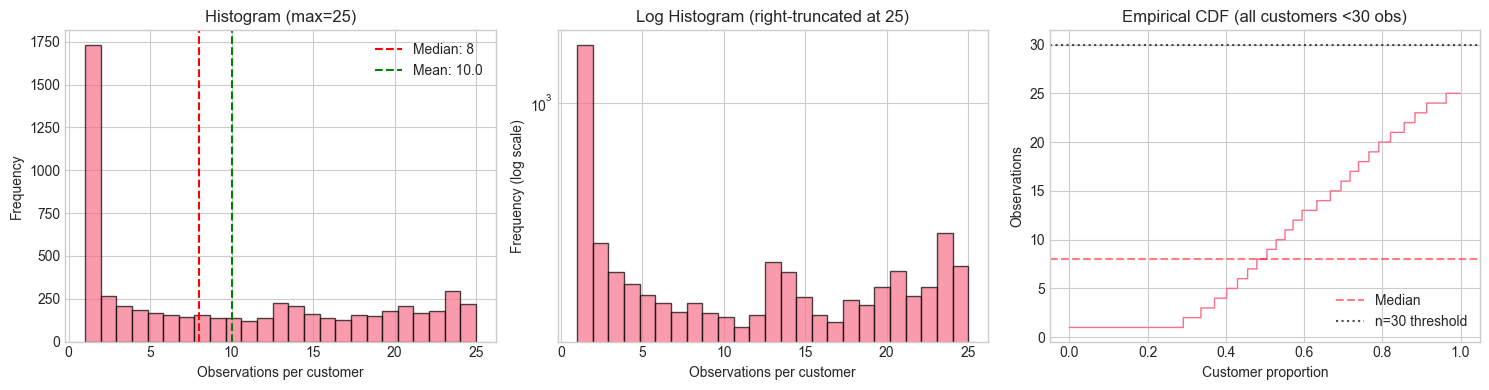

In [37]:

# Visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

obs.hist(ax=ax[0], bins=25, edgecolor='black', alpha=0.7)
ax[0].axvline(obs.median(), color='red', linestyle='--', label=f'Median: {obs.median():.0f}')
ax[0].axvline(obs.mean(), color='green', linestyle='--', label=f'Mean: {obs.mean():.1f}')
ax[0].set_xlabel('Observations per customer')
ax[0].set_ylabel('Frequency')
ax[0].set_title(f'Histogram (max={obs.max()})')
ax[0].legend()

obs.hist(ax=ax[1], bins=25, log=True, edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Observations per customer')
ax[1].set_ylabel('Frequency (log scale)')
ax[1].set_title('Log Histogram (right-truncated at 25)')

obs_sorted = obs.sort_values().reset_index(drop=True)
ax[2].plot(obs_sorted.index / len(obs_sorted), obs_sorted.values, drawstyle='steps-post', linewidth=1)
ax[2].set_xlabel('Customer proportion')
ax[2].set_ylabel('Observations')
ax[2].set_title('Empirical CDF (all customers <30 obs)')
ax[2].axhline(obs.quantile(0.5), color='red', linestyle='--', alpha=0.5, label='Median')
ax[2].axhline(30, color='black', linestyle=':', alpha=0.7, label='n=30 threshold')
ax[2].legend()

plt.tight_layout()
plt.show()

In [38]:
# Temporal structure
df_sample['snapshot_date'] = pd.to_datetime(df_sample['snapshot_date'])
dates = sorted(df_sample['snapshot_date'].unique())
intervals = np.diff(dates)
interval_days = np.array([i.days for i in intervals])

print("TEMPORAL STRUCTURE")
print(f"Date range: {dates[0].date()} → {dates[-1].date()} ({len(dates)} unique dates)")
print(f"Timespan: {(dates[-1] - dates[0]).days} days ({len(dates)} snapshots)")
print(f"Snapshot intervals (days): mean={interval_days.mean():.1f}, median={np.median(interval_days):.1f}, std={interval_days.std():.1f}")


TEMPORAL STRUCTURE
Date range: 2009-12-01 → 2011-12-01 (25 unique dates)
Timespan: 730 days (25 snapshots)
Snapshot intervals (days): mean=30.4, median=31.0, std=0.9


In [39]:
# Right-censoring analysis
last_date = dates[-1]
customers_last_seen = df_sample.groupby('customer_id')['snapshot_date'].max()
right_censored = (customers_last_seen == last_date).sum()
print(f"Right-censored customers (active at end): {right_censored} ({right_censored/len(obs)*100:.1f}%)")

Right-censored customers (active at end): 686 (11.5%)


In [40]:
# Store metadata
OBS_METADATA = {
    'obs_per_customer': obs,
    'max_obs': obs.max(),
    'mean_obs': obs.mean(),
    'customers_by_tier': {
        'exclude_n5': obs[obs < 5].index.tolist(),
        'basic_stats_n5_9': obs[(obs >= 5) & (obs < 10)].index.tolist(),
        'limited_n10_19': obs[(obs >= 10) & (obs < 20)].index.tolist(),
        'marginal_n20_25': obs[(obs >= 20)].index.tolist()
    },
    'gini': gini,
    'right_censored_prop': right_censored / n_total,
    'n_snapshots': len(dates),
    'median_interval_days': np.median(interval_days) if len(interval_days) > 0 else None
}

In [41]:
# Does each cutomer behave like a predictable , stable process?
# ============================================================================
# PURPOSE:
# For each customer, i will analyze their behavioural patterns across 4 variables:
# - recency_days: Time between activities (dormancy indicator)
# - frequency: How often they act (engagement level)
# - monetary_value: How much they spend (value indicator)
# - months_since_first_purchase: Tenure (temporal position)
#
# For EACH customer, i compute statistics that reveal their BEHAVIOURAL TYPE:
# - Stable loyal (low variability, regular patterns)
# - Burst buyer (long gaps then clusters of activity)
# - Whale (rare huge transactions)
# - Dormant (fading activity over time)
# - Volatile spender (unpredictable)
#
# CRITICAL CONSTRAINT :
# Maximum 25 observations per customer → traditional statistics unreliable
# SOLUTION: Bootstrap confidence intervals + Bayesian shrinkage + explicit uncertainty

In [42]:
from scipy.stats import bootstrap
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"\nPart Customer Observation Summary:")
print(f"  • Total customers: {len(OBS_METADATA['obs_per_customer']):,}")
print(f"  • Max observations: {OBS_METADATA['max_obs']}")
print(f"  • Mean observations: {OBS_METADATA['mean_obs']:.1f}")



Part Customer Observation Summary:
  • Total customers: 5,942
  • Max observations: 25
  • Mean observations: 10.0


In [43]:
# - n < 5: Too sparse for ANY statistical inference (exclude)
# - n 5-9: Basic statistics possible, but high uncertainty (include with warnings)
# - n 10-19: Limited fitting possible (primary analysis group)
# - n 20-25: Best available data (reference group)

# Filter customers for Part 2 analysis (n >= 5 minimum)
customers_to_analyze = OBS_METADATA['customers_by_tier']['basic_stats_n5_9'] + \
                       OBS_METADATA['customers_by_tier']['limited_n10_19'] + \
                       OBS_METADATA['customers_by_tier']['marginal_n20_25']
print(f"\nCustomers to analyze (n ≥ 5): {len(customers_to_analyze):,} customers")
print(f"   • Excluded (n < 5): {len(OBS_METADATA['customers_by_tier']['exclude_n5']):,} customers")



Customers to analyze (n ≥ 5): 3,554 customers
   • Excluded (n < 5): 2,388 customers


In [44]:
# helper functions for statistical computation

def compute_bootstrap_ci(data, statistic=np.mean, n_resamples=1000, confidence_level=0.95):
    """
    What bootstrap does
    
    Bootstrap repeatedly:
        Randomly samples from the data with replacement
        Computes the statistic each time
        Uses the distribution of results to estimate a confidence interval
    """
    if len(data) < 4:  # Too few observations for stable bootstrap
        return np.nan, np.nan
    
    try:
        # Perform bootstrap resampling
        res = bootstrap((data,), statistic, n_resamples=n_resamples, 
                       confidence_level=confidence_level, method='percentile')
        return res.confidence_interval.low, res.confidence_interval.high
    except:
        return np.nan, np.nan

def classify_behavioural_archetype(stats_dict):
    """
    Classify customer into behavioural archetype based on statistics.
    
    This is the core INTERPRETATION function that translates numbers into behaviour.
    """
    cv = stats_dict.get('cv', np.nan)
    skew = stats_dict.get('skewness', np.nan)
    zero_prop = stats_dict.get('zero_proportion', np.nan)
    mean_freq = stats_dict.get('mean', np.nan)
    
    # Rule-based classification (thresholds derived from marketing science literature)
    if zero_prop > 0.8 and mean_freq < 0.1:
        return "Dormant", "Customer shows minimal activity; effectively inactive"
    
    if cv < 0.3 and zero_prop < 0.1:
        return "Clockwork", "Highly regular behaviour; predictable timing and amount"
    
    if cv > 1.0 and skew > 1.0:
        return "Burst Buyer", "Long inactivity periods punctuated by clusters of activity"
    
    if cv > 1.0 and abs(skew) < 0.5:
        return "Volatile Spender", "Random, unpredictable behaviour with no clear pattern"
    
    if stats_dict.get('p95_p50_ratio', 0) > 5:
        return "Whale", "Rare but extremely high-value transactions dominate total value"
    
    if zero_prop > 0.5:
        return "Sporadic", "Active less than half the time; intermittent engagement"
    
    return "Regular", "Moderate, typical behaviour without extreme characteristics"

def safe_skewness(x):
    """Compute skewness with stability check (requires n≥20 for reliability)"""
    if len(x) < 4:
        return np.nan
    if len(x) < 20:
        # Flag as unstable but still compute for reference
        return stats.skew(x)
    return stats.skew(x)

def safe_kurtosis(x):
    """Kurtosis is UNRELIABLE for n<50 - we will not report it"""
    if len(x) < 50:
        return np.nan  # Not reliable given our max n=25
    return stats.kurtosis(x)


In [45]:
# CUSTOMER-LEVEL STATISTICS COMPUTATION

print("\n Computing behavioural statistics for each customer...")

# Initialize storage for all customer statistics
customer_stats_list = []

# Track progress
customers_processed = 0
customers_with_warnings = 0

# Iterate through each customer
for customer_id in customers_to_analyze:
    # Extract customer's data
    customer_data = df_sample[df_sample['customer_id'] == customer_id].copy()
    n_obs = len(customer_data)
    
    # Determine observation tier (from Part 1)
    if n_obs < 10:
        tier = "basic_stats_only"
        reliability = "low"
    elif n_obs < 20:
        tier = "limited_fitting"
        reliability = "moderate"
    else:
        tier = "marginal"
        reliability = "best_available"
    
    # Dictionary to store this customer's stats
    cust_stats = {
        'customer_id': customer_id,
        'n_obs': n_obs,
        'tier': tier,
        'data_reliability': reliability
    }
    
    # ========================================================================
    # Analyze EACH variable
    # ========================================================================
    
    for variable in ['recency_days', 'frequency', 'monetary_value']:
        values = customer_data[variable].values
        
        # Skip if all values are identical (no variation)
        if len(np.unique(values)) == 1:
            cust_stats[f'{variable}_constant'] = True
            cust_stats[f'{variable}_mean'] = values[0]
            cust_stats[f'{variable}_cv'] = 0
            cust_stats[f'{variable}_interpretation'] = "Constant behaviour - no variation detected"
            continue
        else:
            cust_stats[f'{variable}_constant'] = False
        
        # ----- CENTRAL TENDENCY -----
        mean_val = np.mean(values)
        median_val = np.median(values)
        cust_stats[f'{variable}_mean'] = mean_val
        cust_stats[f'{variable}_median'] = median_val
        
        # BEHAVIOURAL INTERPRETATION OF MEAN VS MEDIAN
        if mean_val > median_val * 1.2:
            cust_stats[f'{variable}_mean_median_pattern'] = "right_skewed"
            skew_interpretation = "Occasional high spikes pull average above typical level"
        elif median_val > mean_val * 1.2:
            cust_stats[f'{variable}_mean_median_pattern'] = "left_skewed"
            skew_interpretation = "Occasional low dips pull average below typical level"
        else:
            cust_stats[f'{variable}_mean_median_pattern'] = "symmetric"
            skew_interpretation = "Balanced behaviour, typical value representative"
        
        # ----- DISPERSION (VOLATILITY) -----
        std_val = np.std(values)
        cv_val = std_val / mean_val if mean_val > 0 else np.nan
        cust_stats[f'{variable}_std'] = std_val
        cust_stats[f'{variable}_cv'] = cv_val
        
        # BEHAVIOURAL INTERPRETATION OF CV
        if cv_val < 0.3:
            volatility_interpretation = "stable"
        elif cv_val < 0.7:
            volatility_interpretation = "moderate"
        elif cv_val < 1.5:
            volatility_interpretation = "high"
        else:
            volatility_interpretation = "extreme"
        
        # ----- SHAPE (ASYMMETRY) -----
        # CRITICAL WARNING: Skewness requires n≥20 for stability
        skew_val = safe_skewness(values)
        cust_stats[f'{variable}_skewness'] = skew_val
        
        if not np.isnan(skew_val):
            if n_obs < 20:
                skew_reliability = "UNSTABLE - n<20, use for direction only"
            else:
                skew_reliability = "Moderately stable"
            
            if skew_val > 0.5:
                shape_interpretation = "Right-skewed: usually low values, occasional high spikes"
            elif skew_val < -0.5:
                shape_interpretation = "Left-skewed: usually high values, occasional low dips"
            else:
                shape_interpretation = "symmetric"
        else:
            shape_interpretation = "Cannot compute (insufficient data)"
            skew_reliability = "N/A"
        
        # ----- SPARSITY & INTERMITTENCY -----
        zero_prop = np.sum(values == 0) / len(values) if len(values) > 0 else np.nan
        positive_prop = np.sum(values > 0) / len(values)
        cust_stats[f'{variable}_zero_proportion'] = zero_prop
        cust_stats[f'{variable}_positive_proportion'] = positive_prop
        
        # BEHAVIOURAL INTERPRETATION OF ZERO PROPORTION
        if zero_prop == 0:
            intermittency_interpretation = "Always active/present in every period"
        elif zero_prop < 0.3:
            intermittency_interpretation = "Mostly active, occasional inactivity"
        elif zero_prop < 0.7:
            intermittency_interpretation = "Moderately intermittent (active about half the time)"
        else:
            intermittency_interpretation = "Highly intermittent (mostly inactive, rare activity)"
        
        # ----- RANGE & EXTREMES -----
        min_val = np.min(values)
        max_val = np.max(values)
        range_val = max_val - min_val
        cust_stats[f'{variable}_min'] = min_val
        cust_stats[f'{variable}_max'] = max_val
        cust_stats[f'{variable}_range'] = range_val
        
        # ----- QUANTILES (CONCENTRATION MEASURES) -----
        # Note: Extreme quantiles (1%, 99%) unreliable for n<100
        # We compute only stable quantiles
        try:
            p25 = np.percentile(values, 25)
            p50 = np.percentile(values, 50)  # Same as median
            p75 = np.percentile(values, 75)
            p95 = np.percentile(values, 95) if n_obs >= 20 else np.nan
            
            cust_stats[f'{variable}_p25'] = p25
            cust_stats[f'{variable}_p75'] = p75
            cust_stats[f'{variable}_p95'] = p95
            
            # Concentration ratio (how much bigger are top 5% than typical?)
            if not np.isnan(p95) and p50 > 0:
                p95_p50_ratio = p95 / p50
                cust_stats[f'{variable}_p95_p50_ratio'] = p95_p50_ratio
                
                if p95_p50_ratio > 5:
                    concentration_interpretation = "Extreme concentration (whale-like behaviour)"
                elif p95_p50_ratio > 2:
                    concentration_interpretation = "High concentration (few transactions dominate)"
                else:
                    concentration_interpretation = "Moderate concentration (typical distribution)"
        except:
            pass
        
        # ----- BOOTSTRAP CONFIDENCE INTERVALS (for mean) -----
        # WHY: With small n, point estimate may be misleading
        ci_low, ci_high = compute_bootstrap_ci(values, statistic=np.mean)
        cust_stats[f'{variable}_mean_ci_low'] = ci_low
        cust_stats[f'{variable}_mean_ci_high'] = ci_high
        
        # Calculate CI width as percentage of mean (uncertainty measure)
        if not np.isnan(ci_low) and not np.isnan(ci_high) and mean_val > 0:
            ci_width_pct = (ci_high - ci_low) / mean_val
            cust_stats[f'{variable}_mean_uncertainty_pct'] = ci_width_pct
            
            if ci_width_pct > 1.0:
                uncertainty_interpretation = "HIGH UNCERTAINTY - CI wider than the mean itself"
            elif ci_width_pct > 0.5:
                uncertainty_interpretation = "Moderate uncertainty - use with caution"
            else:
                uncertainty_interpretation = "Relatively precise given data constraints"
        else:
            uncertainty_interpretation = "Cannot compute (insufficient data for bootstrap)"
        
        # ----- STORE COMBINED INTERPRETATION -----
        cust_stats[f'{variable}_interpretation'] = f"""
        {variable.upper()} BEHAVIOURAL PROFILE:
        • Typical value: {mean_val:.2f} (median: {median_val:.2f}) - {skew_interpretation}
        • Volatility: {volatility_interpretation} (CV={cv_val:.2f})
        • Activity pattern: {intermittency_interpretation} (zero proportion={zero_prop:.2f})
        • Estimate uncertainty: {uncertainty_interpretation}
        • Shape: {shape_interpretation}
        """
        
        if variable == 'monetary_value' and 'p95_p50_ratio' in cust_stats:
            cust_stats[f'{variable}_interpretation'] += f"\n        • Concentration: {cust_stats.get(f'{variable}_p95_p50_ratio', np.nan):.1f}x multiplier for top purchases"
    
    # ========================================================================
    # SPECIAL HANDLING: months_since_first_purchase (temporal index)
    # ========================================================================
    # This variable is different - it always increases over time
    # Useful for detecting trends in other variables
    
    months_since = customer_data['months_since_first_purchase'].values
    
    # Check if observations are evenly spaced (indicates regular snapshots)
    if len(months_since) > 1:
        diffs = np.diff(months_since)
        is_regular_snapshot = np.allclose(diffs, diffs[0], rtol=0.1)
        cust_stats['has_regular_snapshots'] = is_regular_snapshot
    
    # ========================================================================
    # BEHAVIOURAL ARCHETYPE CLASSIFICATION
    # ========================================================================
    
    # Create a summary stats dict for classification
    classification_stats = {
        'cv': cust_stats.get('recency_days_cv', np.nan),
        'skewness': cust_stats.get('recency_days_skewness', np.nan),
        'zero_proportion': cust_stats.get('recency_days_zero_proportion', np.nan),
        'mean': cust_stats.get('frequency_mean', np.nan),
        'p95_p50_ratio': cust_stats.get('monetary_value_p95_p50_ratio', np.nan)
    }
    
    archetype, archetype_reason = classify_behavioural_archetype(classification_stats)
    cust_stats['behavioural_archetype'] = archetype
    cust_stats['archetype_reason'] = archetype_reason
    
    # Track warnings for customers with insufficient data
    if n_obs < 10:
        customers_with_warnings += 1
    
    customer_stats_list.append(cust_stats)
    customers_processed += 1
    
    # Progress update every 500 customers
    if customers_processed % 500 == 0:
        print(f"   Processed {customers_processed:,}/{len(customers_to_analyze):,} customers...")

# Convert to DataFrame for easy analysis
customer_stats_df = pd.DataFrame(customer_stats_list)

print(f"\n Completed! Processed {customers_processed:,} customers")
print(f"  Customers with LOW reliability (n<10): {customers_with_warnings}")


 Computing behavioural statistics for each customer...
   Processed 500/3,554 customers...
   Processed 1,000/3,554 customers...
   Processed 1,500/3,554 customers...
   Processed 2,000/3,554 customers...
   Processed 2,500/3,554 customers...
   Processed 3,000/3,554 customers...
   Processed 3,500/3,554 customers...

 Completed! Processed 3,554 customers
  Customers with LOW reliability (n<10): 753


In [46]:
print("\n CUSTOMER ARCHETYPE DISTRIBUTION:")

archetype_counts = customer_stats_df['behavioural_archetype'].value_counts()
archetype_props = archetype_counts / len(customer_stats_df) * 100

for archetype, count in archetype_counts.items():
    prop = archetype_props[archetype]
    print(f"  {archetype:15s}: {count:5,d} customers ({prop:5.1f}%)")

print("\n INTERPRETATION:")
print("  • 'Clockwork' customers are ideal for forecasting - highly predictable")
print("  • 'Burst Buyer' & 'Volatile Spender' need different retention strategies")
print("  • 'Dormant' customers should be excluded from active churn models")
print("  • 'Whale' customers require special handling (high value, rare events)")


 CUSTOMER ARCHETYPE DISTRIBUTION:
  Regular        : 1,973 customers ( 55.5%)
  Burst Buyer    : 1,462 customers ( 41.1%)
  Sporadic       :   100 customers (  2.8%)
  Volatile Spender:    16 customers (  0.5%)
  Whale          :     3 customers (  0.1%)

 INTERPRETATION:
  • 'Clockwork' customers are ideal for forecasting - highly predictable
  • 'Burst Buyer' & 'Volatile Spender' need different retention strategies
  • 'Dormant' customers should be excluded from active churn models
  • 'Whale' customers require special handling (high value, rare events)


In [47]:
print("\nVOLATILITY ANALYSIS (Coefficient of Variation):")

for var in ['recency_days', 'frequency', 'monetary_value']:
    cv_values = customer_stats_df[f'{var}_cv'].dropna()
    if len(cv_values) > 0:
        print(f"\n  {var.upper()}:")
        print(f"    Mean CV: {cv_values.mean():.2f}")
        print(f"    Median CV: {cv_values.median():.2f}")
        print(f"    % with CV > 1 (high volatility): {(cv_values > 1).mean()*100:.1f}%")
        print(f"    % with CV < 0.3 (stable): {(cv_values < 0.3).mean()*100:.1f}%")


VOLATILITY ANALYSIS (Coefficient of Variation):

  RECENCY_DAYS:
    Mean CV: 1.31
    Median CV: 1.16
    % with CV > 1 (high volatility): 67.6%
    % with CV < 0.3 (stable): 2.6%

  FREQUENCY:
    Mean CV: 0.95
    Median CV: 0.65
    % with CV > 1 (high volatility): 21.0%
    % with CV < 0.3 (stable): 5.0%

  MONETARY_VALUE:
    Mean CV: 0.25
    Median CV: 0.15
    % with CV > 1 (high volatility): 1.2%
    % with CV < 0.3 (stable): 83.6%


In [48]:
print("\n INTERMITTENCY ANALYSIS (Zero Proportion):")
print("-" * 50)

for var in ['recency_days', 'frequency', 'monetary_value']:
    zero_props = customer_stats_df[f'{var}_zero_proportion'].dropna()
    if len(zero_props) > 0:
        print(f"\n  {var.upper()}:")
        print(f"    Mean zero proportion: {zero_props.mean():.2f}")
        print(f"    % highly intermittent (>0.7 zeros): {(zero_props > 0.7).mean()*100:.1f}%")
        print(f"    % always active (zero zeros): {(zero_props == 0).mean()*100:.1f}%")



 INTERMITTENCY ANALYSIS (Zero Proportion):
--------------------------------------------------

  RECENCY_DAYS:
    Mean zero proportion: 0.42
    % highly intermittent (>0.7 zeros): 11.2%
    % always active (zero zeros): 0.0%

  FREQUENCY:
    Mean zero proportion: 0.24
    % highly intermittent (>0.7 zeros): 14.1%
    % always active (zero zeros): 27.4%

  MONETARY_VALUE:
    Mean zero proportion: 0.00
    % highly intermittent (>0.7 zeros): 0.1%
    % always active (zero zeros): 99.6%


In [49]:
print("\n RELIABILITY ASSESSMENT BY OBSERVATION TIER:")
print("-" * 50)

for tier in ['basic_stats_only', 'limited_fitting', 'marginal']:
    tier_customers = customer_stats_df[customer_stats_df['tier'] == tier]
    if len(tier_customers) > 0:
        print(f"\n  {tier.upper()} (n={len(tier_customers)} customers):")
        
        # Check bootstrap uncertainty
        monetary_uncertainty = tier_customers['monetary_value_mean_uncertainty_pct'].dropna()
        if len(monetary_uncertainty) > 0:
            high_uncertainty_pct = (monetary_uncertainty > 0.5).mean() * 100
            print(f"    • High uncertainty (>50% CI width): {high_uncertainty_pct:.1f}%")
        
        # Skewness reliability
        skew_reliable = tier_customers[tier_customers['n_obs'] >= 20]
        print(f"    • Reliable skewness estimates: {len(skew_reliable)} customers ({len(skew_reliable)/len(tier_customers)*100:.1f}%)")


 RELIABILITY ASSESSMENT BY OBSERVATION TIER:
--------------------------------------------------

  BASIC_STATS_ONLY (n=753 customers):
    • High uncertainty (>50% CI width): 11.4%
    • Reliable skewness estimates: 0 customers (0.0%)

  LIMITED_FITTING (n=1559 customers):
    • High uncertainty (>50% CI width): 4.8%
    • Reliable skewness estimates: 0 customers (0.0%)

  MARGINAL (n=1242 customers):
    • High uncertainty (>50% CI width): 2.5%
    • Reliable skewness estimates: 1242 customers (100.0%)


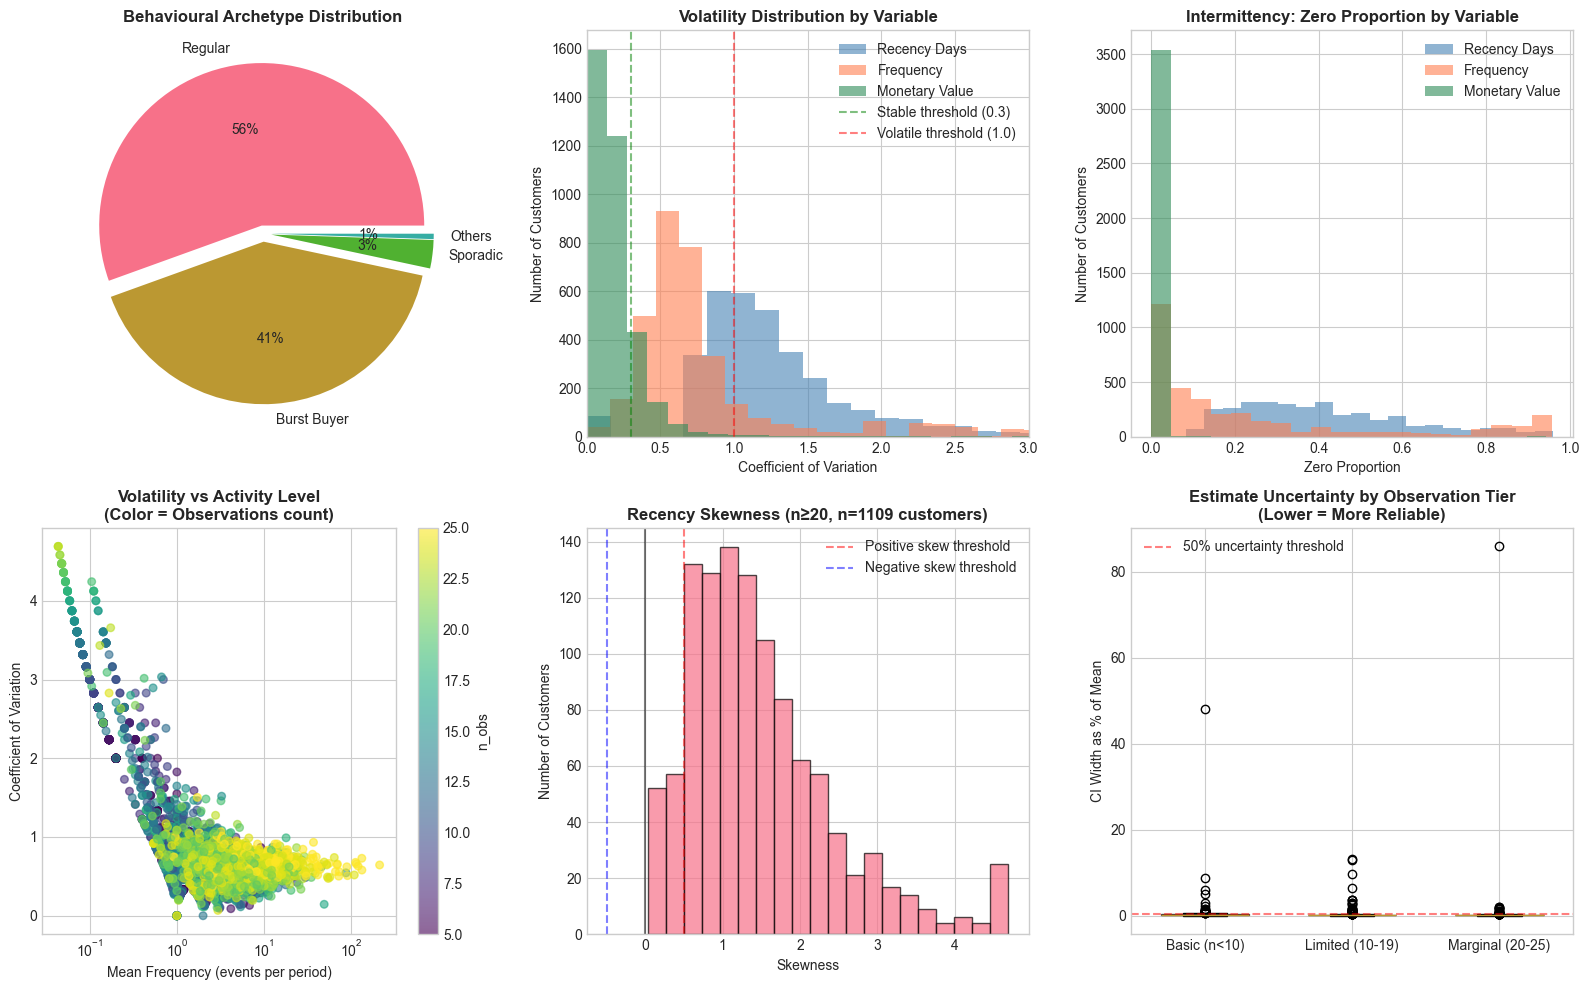

In [50]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Archetype Distribution Pie Chart
# Combine small categories into "Others"
threshold = 0.02  # 2%

# Convert to proportions
proportions = archetype_counts / archetype_counts.sum()

archetype_grouped = archetype_counts.copy()

small_categories = proportions[proportions < threshold].index

if len(small_categories) > 0:
    others_total = archetype_grouped[small_categories].sum()
    
    # Drop small categories
    archetype_grouped = archetype_grouped.drop(small_categories)
    
    # Add Others
    archetype_grouped['Others'] = others_total

# Plot
archetype_grouped.plot(
    kind='pie',
    ax=axes[0,0],
    autopct='%1.0f%%',
    explode=[0.05] * len(archetype_grouped)
)

axes[0,0].set_title(
    'Behavioural Archetype Distribution',
    fontsize=12,
    fontweight='bold'
)

axes[0,0].set_ylabel('')
# CV Distribution (Volatility)
for var, color, idx in [('recency_days', 'steelblue', 0), 
                        ('frequency', 'coral', 1), 
                        ('monetary_value', 'seagreen', 2)]:
    cv_vals = customer_stats_df[f'{var}_cv'].dropna()
    cv_vals = cv_vals[cv_vals < 5]  # Cap for visualization
    axes[0,1].hist(cv_vals, bins=30, alpha=0.6, label=var.replace('_', ' ').title(), color=color)
axes[0,1].set_xlabel('Coefficient of Variation')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].set_title('Volatility Distribution by Variable', fontsize=12, fontweight='bold')
axes[0,1].axvline(0.3, color='green', linestyle='--', alpha=0.5, label='Stable threshold (0.3)')
axes[0,1].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Volatile threshold (1.0)')
axes[0,1].legend()
axes[0,1].set_xlim(0, 3)

#  Zero Proportion Distribution
for var, color, idx in [('recency_days', 'steelblue', 0), 
                        ('frequency', 'coral', 1), 
                        ('monetary_value', 'seagreen', 2)]:
    zero_props = customer_stats_df[f'{var}_zero_proportion'].dropna()
    axes[0,2].hist(zero_props, bins=20, alpha=0.6, label=var.replace('_', ' ').title(), color=color)
axes[0,2].set_xlabel('Zero Proportion')
axes[0,2].set_ylabel('Number of Customers')
axes[0,2].set_title('Intermittency: Zero Proportion by Variable', fontsize=12, fontweight='bold')
axes[0,2].legend()

# Mean vs CV Scatter (identifies volatility clusters)
valid_data = customer_stats_df.dropna(subset=['frequency_mean', 'frequency_cv'])
valid_data = valid_data[valid_data['frequency_cv'] < 5]  # Cap outliers
scatter = axes[1,0].scatter(valid_data['frequency_mean'], valid_data['frequency_cv'], 
                            c=valid_data['n_obs'], cmap='viridis', alpha=0.6, s=30)
axes[1,0].set_xlabel('Mean Frequency (events per period)')
axes[1,0].set_ylabel('Coefficient of Variation')
axes[1,0].set_title('Volatility vs Activity Level\n(Color = Observations count)', fontsize=12, fontweight='bold')
axes[1,0].set_xscale('log')
plt.colorbar(scatter, ax=axes[1,0], label='n_obs')

# Skewness Distribution (where reliable)
reliable_skew = customer_stats_df[customer_stats_df['n_obs'] >= 20]['recency_days_skewness'].dropna()
if len(reliable_skew) > 0:
    axes[1,1].hist(reliable_skew, bins=20, edgecolor='black', alpha=0.7)
    axes[1,1].axvline(0, color='black', linestyle='-', alpha=0.5)
    axes[1,1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Positive skew threshold')
    axes[1,1].axvline(-0.5, color='blue', linestyle='--', alpha=0.5, label='Negative skew threshold')
    axes[1,1].set_xlabel('Skewness')
    axes[1,1].set_ylabel('Number of Customers')
    axes[1,1].set_title(f'Recency Skewness (n≥20, n={len(reliable_skew)} customers)', fontsize=12, fontweight='bold')
    axes[1,1].legend()
else:
    axes[1,1].text(0.5, 0.5, 'Insufficient customers with n≥20\nfor reliable skewness', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Skewness Distribution (Unavailable)')

# Confidence Interval Width (Uncertainty by Tier)
tier_palette = {'basic_stats_only': 'red', 'limited_fitting': 'orange', 'marginal': 'green'}
for tier, color in tier_palette.items():
    tier_data = customer_stats_df[customer_stats_df['tier'] == tier]['monetary_value_mean_uncertainty_pct'].dropna()
    if len(tier_data) > 0:
        axes[1,2].boxplot([tier_data], positions=[list(tier_palette.keys()).index(tier)], 
                         widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.7))
axes[1,2].set_xticklabels(['Basic (n<10)', 'Limited (10-19)', 'Marginal (20-25)'])
axes[1,2].set_ylabel('CI Width as % of Mean')
axes[1,2].set_title('Estimate Uncertainty by Observation Tier\n(Lower = More Reliable)', fontsize=12, fontweight='bold')
axes[1,2].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% uncertainty threshold')
axes[1,2].legend()

plt.tight_layout()
plt.show()


In [51]:
# Count customers suitable for distribution fitting
customers_for_fitting = customer_stats_df[customer_stats_df['n_obs'] >= 15]['customer_id'].tolist()
print(f"\nDistribution Fitting:")
print(f"   Customers suitable for distribution fitting (n≥15): {len(customers_for_fitting):,}")
print(f"   → Will use Method of Moments + Bootstrap (not MLE)")
print(f"   → Will focus on 2-parameter distributions (Gamma, LogNormal)")

# Temporal dynamics readiness
print(f"\n Temporal Dynamics:")
print(f"   Customers with enough data for trend analysis (n≥10): {(customer_stats_df['n_obs'] >= 10).sum():,}")
print(f"   → Cannot use rolling windows (n too small) skip trend analysis")

# Clustering readiness
print(f"\nCross-Customer Clustering")
print(f"   Customers with complete feature vectors: {len(customer_stats_df):,}")
print(f"   → Will use customer_stats_df as feature matrix")
print(f"   → Features: mean, CV, skewness, zero_prop and other derived features where seeen fit for each variable")
print(f"   → Will apply shrinkage/regularization before clustering")





Distribution Fitting:
   Customers suitable for distribution fitting (n≥15): 1,977
   → Will use Method of Moments + Bootstrap (not MLE)
   → Will focus on 2-parameter distributions (Gamma, LogNormal)

 Temporal Dynamics:
   Customers with enough data for trend analysis (n≥10): 2,801
   → Cannot use rolling windows (n too small) skip trend analysis

Cross-Customer Clustering
   Customers with complete feature vectors: 3,554
   → Will use customer_stats_df as feature matrix
   → Features: mean, CV, skewness, zero_prop and other derived features where seeen fit for each variable
   → Will apply shrinkage/regularization before clustering


In [52]:
 # Save for subsequent parts
PART2_OUTPUT = {
    'customer_stats_df': customer_stats_df,
    'customers_for_fitting': customers_for_fitting,
    'archetype_distribution': archetype_counts.to_dict(),
    'analysis_complete': True
}

In [53]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [54]:

import os
import sys
import json
import io
import pickle
import gzip
import numpy as np
import pandas as pd
from datetime import datetime

def save_pickle(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

def save_gzip_pickle(obj, path):
    with gzip.open(path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)

def save_parquet(df, path):
    df.to_parquet(path, index=False, compression='snappy')



SAVE_DIR = 'saved_analysis_state'

DIRS = {
    'data': os.path.join(SAVE_DIR, 'data'),
    'metadata': os.path.join(SAVE_DIR, 'metadata'),
    'config': os.path.join(SAVE_DIR, 'config'),
    'environment': os.path.join(SAVE_DIR, 'environment'),
    'docs': os.path.join(SAVE_DIR, 'docs')
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

print(f"Save directory: {os.path.abspath(SAVE_DIR)}")

ANALYSIS_CONFIG = {

    # Versioning
    'analysis_version': '1.0.0',

    # Statistical thresholds
    'min_observations_for_analysis': 5,
    'min_observations_for_basic_stats': 5,
    'min_observations_for_variance': 8,
    'min_observations_for_skewness': 20,
    'min_observations_for_distribution': 15,
    'min_observations_for_robust': 30,

    # Bootstrap
    'bootstrap_resamples': 1000,
    'bootstrap_confidence_level': 0.95,

    # Data definitions
    'snapshot_date_col': 'snapshot_date',
    'customer_id_col': 'customer_id',

    # Statistical assumptions
    'right_censoring_handled': True,
    'truncation_at_25_noted': True,
}

RUN_METADATA = {
    'created_at': datetime.now().isoformat(),
    'n_customers_total': len(obs),
    'n_customers_analyzed': len(customers_to_analyze),
    'n_customers_excluded': len(obs) - len(customers_to_analyze),
    'max_observations_available': obs.max(),
    'mean_observations': obs.mean(),
}


df_filtered = df_sample[
    df_sample['customer_id'].isin(customers_to_analyze)
].copy()


assert ANALYSIS_CONFIG['min_observations_for_analysis'] >= 5
assert len(df_filtered) > 0
assert customer_stats_df['customer_id'].nunique() > 0


print("\nSaving DataFrames...")

save_parquet(
    df_filtered,
    os.path.join(DIRS['data'], 'df_filtered.parquet')
)

save_parquet(
    customer_stats_df,
    os.path.join(DIRS['data'], 'customer_stats_df.parquet')
)


print("\nSaving customer_data_dict...")

customer_data_dict = {
    cust_id: group_df[
        ['snapshot_date', 'recency_days',
         'frequency', 'monetary_value',
         'months_since_first_purchase']
    ].copy()

    for cust_id, group_df in df_sample.groupby('customer_id')

    if len(group_df) >= ANALYSIS_CONFIG['min_observations_for_analysis']
}

dict_path = os.path.join(
    DIRS['data'],
    'customer_data_dict.pkl.gz'
)

save_gzip_pickle(customer_data_dict, dict_path)


# Compression report
buffer = io.BytesIO()
pickle.dump(customer_data_dict, buffer)

uncompressed_size = buffer.tell() / (1024 * 1024)
compressed_size = os.path.getsize(dict_path) / (1024 * 1024)

print(f"Compressed {uncompressed_size:.2f} MB → {compressed_size:.2f} MB")


# ============================================================================
# SAVE METADATA + CONFIG
# ============================================================================

print("\nSaving metadata/config...")

save_pickle(
    OBS_METADATA,
    os.path.join(DIRS['metadata'], 'obs_metadata.pkl')
)

save_pickle(
    PART2_OUTPUT,
    os.path.join(DIRS['metadata'], 'part2_output.pkl')
)

save_pickle(
    ANALYSIS_CONFIG,
    os.path.join(DIRS['config'], 'analysis_config.pkl')
)

save_pickle(
    RUN_METADATA,
    os.path.join(DIRS['metadata'], 'run_metadata.pkl')
)


# ============================================================================
# SAVE ENVIRONMENT INFO
# ============================================================================

import scipy
import sklearn

ENVIRONMENT_INFO = {
    'python_version': sys.version,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
    'scipy_version': scipy.__version__,
    'sklearn_version': sklearn.__version__,
}

save_pickle(
    ENVIRONMENT_INFO,
    os.path.join(DIRS['environment'], 'environment_info.pkl')
)


# ============================================================================
# IMPROVEMENT 5: MANIFEST FILE
# - Central registry of saved artifacts
# - Makes future loading easier/scalable
# ============================================================================

MANIFEST = {
    'df_filtered': 'data/df_filtered.parquet',
    'customer_stats_df': 'data/customer_stats_df.parquet',
    'customer_data_dict': 'data/customer_data_dict.pkl.gz',
    'obs_metadata': 'metadata/obs_metadata.pkl',
    'part2_output': 'metadata/part2_output.pkl',
    'run_metadata': 'metadata/run_metadata.pkl',
    'analysis_config': 'config/analysis_config.pkl',
    'environment_info': 'environment/environment_info.pkl'
}

with open(os.path.join(SAVE_DIR, 'manifest.json'), 'w') as f:
    json.dump(MANIFEST, f, indent=2)


# ============================================================================
# README
# ============================================================================

readme_content = f"""
# Analysis State Directory

## Version
{ANALYSIS_CONFIG['analysis_version']}

## Customers
{RUN_METADATA['n_customers_analyzed']:,} analyzed /
{RUN_METADATA['n_customers_total']:,} total

## Statistical Thresholds
- analysis: {ANALYSIS_CONFIG['min_observations_for_analysis']}
- skewness: {ANALYSIS_CONFIG['min_observations_for_skewness']}
- distribution fitting: {ANALYSIS_CONFIG['min_observations_for_distribution']}

## Notes
Customers with fewer than
{ANALYSIS_CONFIG['min_observations_for_analysis']}
observations are excluded from inferential analysis.
"""

with open(
    os.path.join(DIRS['docs'], 'README.md'),
    'w',
    encoding='utf-8'
) as f:
    f.write(readme_content)


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SAVE COMPLETE")
print("="*70)

for root, _, files in os.walk(SAVE_DIR):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / 1024

        print(
            f"{path:<70} "
            f"{size/1024:.2f} MB" if size > 1024
            else f"{path:<70} {size:.1f} KB"
        )

Save directory: C:\Users\abduh\OneDrive\Desktop\easy_\eda\notebooks\saved_analysis_state

Saving DataFrames...

Saving customer_data_dict...
Compressed 4.13 MB → 0.70 MB

Saving metadata/config...

SAVE COMPLETE
saved_analysis_state\manifest.json                                     0.4 KB
saved_analysis_state\.ipynb_checkpoints\manifest-checkpoint.json       0.4 KB
saved_analysis_state\config\analysis_config.pkl                        0.4 KB
saved_analysis_state\data\customer_data_dict.pkl.gz                    719.2 KB
saved_analysis_state\data\customer_stats_df.parquet                    1.26 MB
saved_analysis_state\data\df_filtered.parquet                          530.7 KB
saved_analysis_state\data\fit_df.parquet                               1.57 MB
saved_analysis_state\data\k_means.parquet                              16.7 KB
saved_analysis_state\data\scaled_features.parquet                      349.5 KB
saved_analysis_state\docs\README.md                                    0.3 KB